# Занятие 36. Практика: почини сломанный прод RankPulse

**Теория:** `Урок_35_Boosting_Теория/35_Градиентный_бустинг.ipynb` (занятие 35).  
**Сюжет:** **RankPulse Control Room** — ночной дежурный получил тикет: «прогноз следующего MMR игроков разъехался».  
**Задача:** регрессия `next_mmr`; главная метрика — **MAE** (средняя абсолютная ошибка). RMSE — рядом.  
**Модельный фокус:** после ремонта сравнить **XGBoost**, **LightGBM**, **CatBoost** (+ починенный `HistGradientBoosting` как ориентир).

> Авторский ноутбук **с решениями**. Студентам выдаётся копия без готовых ответов.  
> Рядом лежат другие варианты: `Урок_36_Boosting_Практика_rankpulse.ipynb`, `…_legacy.ipynb` — их не трогаем.


## Легенда: инцидент в Control Room

Платформа **RankPulse** подсказывает матчмейкингу ожидаемый **следующий MMR** игрока. Вчера выкатили «ускоренный» бустинг-пайплайн — и validation MAE вырос, а на дашборде всё «зелёное», потому что смотрели на train.

Вам дали **сломанный baseline-скрипт** (блок «Дано» ниже). Типичные поломки бустинга уже внутри — с пометками симптомов. Ваша работа:

1. **Воспроизвести инцидент** (плохие метрики / график: train↓, val↑).
2. По чек-листу **найти и починить** баги (каждое задание — отдельный ремонт).
3. В конце выкатить честное сравнение **внешних** библиотек с early stopping по validation.
4. Написать короткий **postmortem**: что сломалось → как починили → кого выкатываем.


## Что нужно сделать

1. Запустить сломанный пайплайн и зафиксировать симптомы.
2. Починить пару `learning_rate` + early stopping (монитор — **validation**, не train).
3. Убрать утечку: scaler / кодирование только с `fit` на train.
4. Сравнивать модели по **validation MAE**, не по train.
5. Починить «кривые» параметры внешних библиотек и поставить честный sklearn HistGBM.
6. Обучить **XGBoost + LightGBM + CatBoost** с корректным early stopping.
7. Собрать рейтинг, один раз проверить победителя на test (не выбирая модель по test).
8. Написать postmortem.

### Оценивание (30 баллов)

| № | Тема | Баллы |
|---|------|------:|
| 1 | Воспроизвести инцидент | 3 |
| 2 | Починить learning_rate и early stopping | 4 |
| 3 | Починить утечку preprocessing | 4 |
| 4 | Сравнивать по validation MAE | 3 |
| 5 | Починить параметры и HistGBM-ориентир | 4 |
| 6 | Внешние бустинги после ремонта | 7 |
| 7 | Рейтинг и честный test | 3 |
| 8 | Postmortem | 2 |
| | **Итого** | **30** |


---
## Среда и библиотеки

В учебной среде `xgboost`, `lightgbm` и `catboost` обычно уже установлены. Если импорт падает дома:

```bash
pip install xgboost lightgbm catboost
```


In [1]:
# Дома (если нужно): pip install xgboost lightgbm catboost
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor, GradientBoostingRegressor

RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.25  # 25% от train_val ≈ 20% всех данных
PRIMARY_METRIC = "MAE"
N_PLAYERS = 800


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_regression(model_name, y_true, y_pred, fit_time_sec=None):
    row = {
        "model": model_name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
    }
    if fit_time_sec is not None:
        row["fit_time_sec"] = float(fit_time_sec)
    return row


def staged_mae_curves(model, X_tr, y_tr, X_va, y_va):
    """MAE после каждого дерева (sklearn GradientBoosting / совместимые)."""
    train_mae, val_mae = [], []
    for pred_tr, pred_va in zip(
        model.staged_predict(X_tr),
        model.staged_predict(X_va),
    ):
        train_mae.append(mean_absolute_error(y_tr, pred_tr))
        val_mae.append(mean_absolute_error(y_va, pred_va))
    return np.asarray(train_mae), np.asarray(val_mae)


print("PRIMARY_METRIC =", PRIMARY_METRIC)


PRIMARY_METRIC = MAE


---
## Данные матчмейкинга (даны рабочими)

Синтетический лог ~800 игроков RankPulse. Признаки: винрейт, матчи, роль, часы, текущий MMR, стрик, KDA, доля пати. Цель — `next_mmr`.


In [2]:
rng = np.random.default_rng(RANDOM_STATE)

roles = rng.choice(
    ["carry", "mid", "support", "offlane"],
    size=N_PLAYERS,
    p=[0.30, 0.25, 0.25, 0.20],
)
role_effect = {"carry": 35.0, "mid": 20.0, "support": -15.0, "offlane": 10.0}

winrate = rng.beta(5.5, 4.5, N_PLAYERS)
matches_played = rng.integers(80, 2200, N_PLAYERS)
hours_played = rng.integers(120, 5200, N_PLAYERS)
current_mmr = rng.integers(1200, 4800, N_PLAYERS).astype(float)
streak = rng.integers(-6, 12, N_PLAYERS)
avg_kda = rng.uniform(1.2, 6.5, N_PLAYERS)
party_rate = rng.uniform(0.0, 1.0, N_PLAYERS)

noise = rng.normal(0.0, 55.0, N_PLAYERS)
next_mmr = (
    current_mmr
    + 220.0 * (winrate - 0.5)
    + 0.015 * matches_played
    + 0.004 * hours_played
    + 9.0 * streak
    + 18.0 * avg_kda
    - 25.0 * party_rate
    + np.array([role_effect[r] for r in roles])
    + noise
)

players = pd.DataFrame(
    {
        "winrate": winrate,
        "matches_played": matches_played,
        "role": roles,
        "hours_played": hours_played,
        "current_mmr": current_mmr,
        "streak": streak,
        "avg_kda": avg_kda,
        "party_rate": party_rate,
        "next_mmr": next_mmr,
    }
)

X_raw = pd.get_dummies(players.drop(columns=["next_mmr"]), columns=["role"], dtype=float)
y = players["next_mmr"].copy()

print("players:", players.shape, "| X_raw:", X_raw.shape)
print(players["role"].value_counts())
players.head()


players: (800, 9) | X_raw: (800, 11)
role
carry      244
support    211
mid        191
offlane    154
Name: count, dtype: int64


,winrate,matches_played,role,hours_played,current_mmr,streak,avg_kda,party_rate,next_mmr
0,0.683642,1676,support,1939,2223.0,1,4.000347,0.715124,2392.169206
1,0.692218,422,mid,1782,2177.0,-4,1.889246,0.266606,2239.281863
2,0.566294,1031,offlane,1191,4570.0,9,2.312652,0.555971,4685.422763
3,0.713291,1322,support,5044,3990.0,9,4.889017,0.855312,4174.611627
4,0.693816,521,carry,3504,4294.0,9,2.562853,0.249523,4560.445739


---
## Дано / Сломанный пайплайн

Ниже — **намеренно сломанный** прод-скрипт из Control Room. Запускайте как есть, чтобы увидеть инцидент.  
Симптомы помечены комментариями `BUG-*`. **Не копируйте этот блок в финальный прод** — чините в заданиях.

### Чек-лист тикетов (что искать)

| Код | Симптом в проде | Где смотреть |
|-----|-----------------|--------------|
| **BUG-A** | Validation «подозрительно хорошая», scaler знает про всех | `StandardScaler.fit` на всём `X` до split |
| **BUG-B** | Train MAE падает, val MAE растёт | огромный `learning_rate` + много деревьев, `early_stopping=False` |
| **BUG-C** | Early stopping «есть», но не спасает | мониторят **train**, а не validation |
| **BUG-D** | На дашборде всё зелёное | сравнивают модели только по **train MAE** |
| **BUG-E** | Внешние либы «для скорости» или кривые | `n_estimators=1`, безумный `learning_rate`, отключённый early stopping |
| **BUG-F** | Победитель выбран по test | test использовали для выбора модели |


In [3]:
# === BROKEN PROD v0.9-hotfix (НЕ для выката) ===
# Запустите целиком — это воспроизведение инцидента.

# --- BUG-A: утечка — scaler fit на ВСЕХ данных до split ---
leaky_scaler = StandardScaler()
X_leaky = pd.DataFrame(
    leaky_scaler.fit_transform(X_raw),  # fit видит будущий val/test
    columns=X_raw.columns,
    index=X_raw.index,
)

X_tv, X_test_broken, y_tv, y_test_broken = train_test_split(
    X_leaky, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
X_tr_b, X_va_b, y_tr_b, y_va_b = train_test_split(
    X_tv, y_tv, test_size=VAL_SIZE, random_state=RANDOM_STATE
)

# --- BUG-B: слишком большой learning_rate + много деревьев без early stopping ---
broken_gb = GradientBoostingRegressor(
    n_estimators=250,
    learning_rate=0.85,  # слишком крупный шаг
    max_depth=4,
    random_state=RANDOM_STATE,
)
broken_gb.fit(X_tr_b, y_tr_b)

train_curve_b, val_curve_b = staged_mae_curves(broken_gb, X_tr_b, y_tr_b, X_va_b, y_va_b)

# --- BUG-C: «early stopping», но мониторят train (eval_set = train) ---
# (Иллюстрация на HistGBM: early_stopping выключен; отдельно «монитор train»)
broken_hist = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.4,
    max_depth=8,
    early_stopping=False,  # выключен
    random_state=RANDOM_STATE,
)
broken_hist.fit(X_tr_b, y_tr_b)
# «монитор» только train — так в логах дежурного:
monitor_train_mae = mean_absolute_error(y_tr_b, broken_hist.predict(X_tr_b))
monitor_val_mae = mean_absolute_error(y_va_b, broken_hist.predict(X_va_b))

# --- BUG-D: лидерборд только по train MAE ---
broken_leaderboard = pd.DataFrame(
    [
        {
            "model": "broken_GB (lr=0.85)",
            "train_MAE": mean_absolute_error(y_tr_b, broken_gb.predict(X_tr_b)),
            "val_MAE_hidden": mean_absolute_error(y_va_b, broken_gb.predict(X_va_b)),
        },
        {
            "model": "broken_HistGBM",
            "train_MAE": monitor_train_mae,
            "val_MAE_hidden": monitor_val_mae,
        },
    ]
)

# --- BUG-E: внешние либы сломаны кривыми параметрами ---
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

broken_xgb = XGBRegressor(
    n_estimators=1,  # «для скорости»
    learning_rate=0.05,
    max_depth=4,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
broken_xgb.fit(X_tr_b, y_tr_b)

broken_lgbm = LGBMRegressor(
    n_estimators=400,
    learning_rate=1.5,  # кривой шаг
    num_leaves=128,
    random_state=RANDOM_STATE,
    verbosity=-1,
)
broken_lgbm.fit(X_tr_b, y_tr_b)  # без early stopping / eval_set

broken_cat = CatBoostRegressor(
    iterations=300,
    learning_rate=0.9,
    depth=8,
    loss_function="MAE",
    random_seed=RANDOM_STATE,
    verbose=0,
    # early_stopping выключен / нет eval_set
)
broken_cat.fit(X_tr_b, y_tr_b)

broken_external = pd.DataFrame(
    [
        evaluate_regression("broken_XGB(n=1)", y_tr_b, broken_xgb.predict(X_tr_b)),
        evaluate_regression("broken_LGBM(lr=1.5)", y_tr_b, broken_lgbm.predict(X_tr_b)),
        evaluate_regression("broken_Cat(lr=0.9)", y_tr_b, broken_cat.predict(X_tr_b)),
    ]
)

# --- BUG-F: выбор «победителя» по test ---
candidates = {
    "broken_GB": broken_gb,
    "broken_HistGBM": broken_hist,
    "broken_XGB": broken_xgb,
    "broken_LGBM": broken_lgbm,
    "broken_Cat": broken_cat,
}
test_scores = {
    name: mean_absolute_error(y_test_broken, model.predict(X_test_broken))
    for name, model in candidates.items()
}
fake_winner = min(test_scores, key=test_scores.get)

print("=== Инцидент: кривые переобучения (BUG-B) ===")
print(f"train MAE: start={train_curve_b[0]:.1f} → end={train_curve_b[-1]:.1f}")
print(f"val   MAE: start={val_curve_b[0]:.1f} → end={val_curve_b[-1]:.1f}")
print(f"лучший val на дереве #{int(np.argmin(val_curve_b)) + 1}: {val_curve_b.min():.1f}")
print()
print("=== «Монитор» дежурного (BUG-C) ===")
print(f"train MAE (смотрят на него) = {monitor_train_mae:.1f}")
print(f"val   MAE (реально плохо)   = {monitor_val_mae:.1f}")
print()
print("=== Лидерборд только train (BUG-D) ===")
print(broken_leaderboard.to_string(index=False))
print()
print("=== Внешние «быстрые» (BUG-E), метрики на TRAIN ===")
print(broken_external.to_string(index=False))
print()
print("=== Нечестный выбор по TEST (BUG-F) ===")
print(test_scores)
print("fake_winner =", fake_winner)


=== Инцидент: кривые переобучения (BUG-B) ===
train MAE: start=146.9 → end=0.0
val   MAE: start=147.6 → end=86.3
лучший val на дереве #2: 77.2

=== «Монитор» дежурного (BUG-C) ===
train MAE (смотрят на него) = 0.3
val   MAE (реально плохо)   = 60.2

=== Лидерборд только train (BUG-D) ===
              model  train_MAE  val_MAE_hidden
broken_GB (lr=0.85)   0.000058       86.323217
     broken_HistGBM   0.315714       60.226905

=== Внешние «быстрые» (BUG-E), метрики на TRAIN ===
              model        MAE       RMSE       R2
    broken_XGB(n=1) 826.433396 960.760067 0.094197
broken_LGBM(lr=1.5)   0.000068   0.000085 1.000000
 broken_Cat(lr=0.9)   0.106907   1.529889 0.999998

=== Нечестный выбор по TEST (BUG-F) ===
{'broken_GB': 83.3048820356345, 'broken_HistGBM': 60.06121241504643, 'broken_XGB': 882.5474116151876, 'broken_LGBM': 106.38710001931854, 'broken_Cat': 282.3212943250604}
fake_winner = broken_HistGBM


---
## Задание 1. Воспроизвести инцидент — **3 балла**

Покажите Control Room, что пайплайн действительно сломан: нарисуйте кривую **train MAE ↓** и **val MAE ↑** (или val хуже в конце, чем в середине).

### Что сделать

**Шаг 1.** Используйте `train_curve_b` / `val_curve_b` из блока «Дано» (или пересчитайте `staged_mae_curves` на сломанном `GradientBoostingRegressor`).

**Шаг 2.** Постройте line-график: ось X — номер дерева, ось Y — MAE; две линии (train / val). Заголовок и подписи осей обязательны.

**Шаг 3.** Сохраните в словарь `incident_report` ключи:
- `train_mae_end`, `val_mae_end`, `best_val_mae`, `best_val_trees`;
- `symptom` — короткая фраза (например: «train падает, val растёт»).

### Подробные критерии (для проверки LLM)
- **1.0 балл:** есть график train/val MAE по числу деревьев с заголовком и подписями осей.
- **1.0 балл:** на графике видно ухудшение validation относительно train (или относительно лучшей точки val).
- **1.0 балл:** заполнен `incident_report` с числовыми полями и текстом `symptom`.

### Снижение баллов
- Нет заголовка или подписей осей → минус **0.5**.
- Только train без val → минус **1.0**.
- Нет `incident_report` → минус **1.0**.


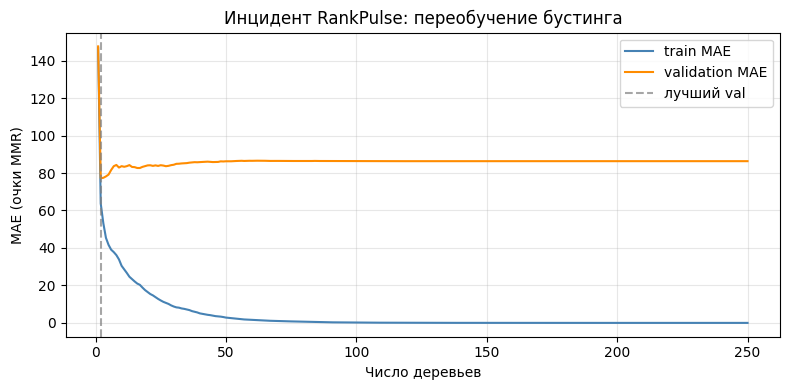

{'train_mae_end': 5.7645679861669424e-05,
 'val_mae_end': 86.32321697166455,
 'best_val_mae': 77.24457161684757,
 'best_val_trees': 2,
 'symptom': 'train MAE падает, validation MAE растёт после раннего минимума'}

In [4]:
# --- Решение задания 1 ---
fig, ax = plt.subplots(figsize=(8, 4))
trees = np.arange(1, len(train_curve_b) + 1)
ax.plot(trees, train_curve_b, label="train MAE", color="steelblue")
ax.plot(trees, val_curve_b, label="validation MAE", color="darkorange")
ax.axvline(np.argmin(val_curve_b) + 1, color="gray", linestyle="--", alpha=0.7, label="лучший val")
ax.set_title("Инцидент RankPulse: переобучение бустинга")
ax.set_xlabel("Число деревьев")
ax.set_ylabel("MAE (очки MMR)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

incident_report = {
    "train_mae_end": float(train_curve_b[-1]),
    "val_mae_end": float(val_curve_b[-1]),
    "best_val_mae": float(val_curve_b.min()),
    "best_val_trees": int(np.argmin(val_curve_b) + 1),
    "symptom": "train MAE падает, validation MAE растёт после раннего минимума",
}
incident_report


---
## Задание 2. Починить learning_rate и early stopping — **4 балла**

Тикеты **BUG-B** и **BUG-C**: уменьшить шаг, включить early stopping и **мониторить validation**, не train.

### Что сделать

**Шаг 1.** Сделайте **честный** split **до** любого scaler (пока без масштабирования или с временным `X_raw`): `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`.

**Шаг 2.** Обучите `HistGradientBoostingRegressor` с умеренным `learning_rate` (например 0.05–0.1), `max_iter` ≥ 300, `early_stopping=True`, `validation_fraction` или отдельный val — как позволяет API. Главное: остановка по **не-train** данным.

**Шаг 3.** Посчитайте MAE на train и на **validation**; сохраните `fixed_es_metrics`. Выведите `n_iter_`.

**Шаг 4.** В markdown (1–2 предложения): почему нельзя останавливаться по train MAE.

### Подробные критерии (для проверки LLM)
- **1.0 балл:** есть честный train / val / test split с `random_state`.
- **1.5 балла:** HistGBM (или GB) обучен с early stopping и умеренным `learning_rate`.
- **1.0 балл:** в `fixed_es_metrics` есть MAE на validation; показано `n_iter_`.
- **0.5 балла:** есть объяснение про монитор validation vs train.

### Снижение баллов
- Early stopping выключен → минус **1.5**.
- Метрики только на train → минус **1.0**.
- Нет объяснения → минус **0.5**.


In [5]:
# --- Решение задания 2 ---
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=VAL_SIZE, random_state=RANDOM_STATE
)

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

t0 = time.perf_counter()
fixed_hist = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=RANDOM_STATE,
)
fixed_hist.fit(X_train, y_train)
fixed_hist_time = time.perf_counter() - t0

fixed_es_metrics = {
    "train_MAE": float(mean_absolute_error(y_train, fixed_hist.predict(X_train))),
    "val_MAE": float(mean_absolute_error(y_val, fixed_hist.predict(X_val))),
    "n_iter_": int(fixed_hist.n_iter_),
    "fit_time_sec": fixed_hist_time,
}
print(fixed_es_metrics)


X_train: (480, 11) X_val: (160, 11) X_test: (160, 11)


{'train_MAE': 25.631315470174854, 'val_MAE': 59.88659322857218, 'n_iter_': 222, 'fit_time_sec': 0.3353691999800503}


*Почему нельзя early stopping по train?*

Train MAE почти всегда падает, пока добавляют деревья: модель подстраивается под уже виденные точки, в том числе под шум. Остановка по train поздно «увидит» переобучение. Нужна **отложенная** выборка (validation): когда ошибка на ней перестаёт улучшаться — пора остановиться.


---
## Задание 3. Починить утечку preprocessing — **4 балла**

Тикет **BUG-A**: `StandardScaler.fit` на всём `X` до split подглядывает в будущие игроков.

### Что сделать

**Шаг 1.** На уже честном split масштабируйте признаки **без утечки**: `StandardScaler`, `fit` только на `X_train`, затем `transform` для train / val / test → `X_train_s`, `X_val_s`, `X_test_s`.

**Шаг 2.** Кратко обучите маленький бустинг (HistGBM или GB) на `X_train_s`, посчитайте val MAE → `honest_scaled_val_mae`.

**Шаг 3.** В markdown объясните: (а) в чём утечка в «Дано»; (б) правильный порядок fit/transform; (в) зачем это важно даже если деревьям scaler не критичен.

### Подробные критерии (для проверки LLM)
- **1.5 балла:** `fit` scaler только на train; val/test только через `transform`.
- **1.0 балл:** есть `honest_scaled_val_mae` (число, MAE на validation).
- **1.5 балла:** markdown с тремя пунктами про утечку / порядок / смысл.

### Снижение баллов
- `fit` на train+val или на всём → минус **1.5**.
- Нет markdown-объяснения → минус **1.5**.


In [6]:
# --- Решение задания 3 ---
scaler = StandardScaler()
X_train_s = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_val_s = pd.DataFrame(
    scaler.transform(X_val), columns=X_val.columns, index=X_val.index
)
X_test_s = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

probe = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=RANDOM_STATE,
)
probe.fit(X_train_s, y_train)
honest_scaled_val_mae = float(mean_absolute_error(y_val, probe.predict(X_val_s)))
print("honest_scaled_val_mae =", round(honest_scaled_val_mae, 2))


honest_scaled_val_mae = 60.8


**Утечка в «Дано».** `StandardScaler.fit_transform(X_raw)` считал среднее и std **по всем игрокам**, включая тех, кто потом попадёт в validation/test. Проверка перестаёт быть «новой».

**Правильный порядок.** `fit` только на train → статистики без будущих игроков; val и test только `transform`.

**Зачем это помнить для бустинга.** Деревьям масштаб часто не критичен, но в Control Room рядом могут стоять линейные модели, нейросети или target encoding. Правило одно: **любой** preprocessing с `fit` — только на train.


---
## Задание 4. Сравнивать по validation MAE — **3 балла**

Тикет **BUG-D**: дашборд смотрел только на train MAE и объявлял успех.

### Что сделать

**Шаг 1.** Обучите две модели на `X_train` (без утечки; масштабирование по желанию — одинаково для обеих):
- «агрессивную» (большой `learning_rate`, без early stopping или с малым терпением);
- «аккуратную» (из задания 2 или аналог с early stopping).

**Шаг 2.** Соберите таблицу `honest_leaderboard` с колонками `model`, `train_MAE`, `val_MAE`.

**Шаг 3.** Выберите временного лидера `interim_leader` **по минимальному val_MAE** (не по train).

**Шаг 4.** Bar-график: сравнение train vs val MAE для обеих моделей (заголовок + подписи).

### Подробные критерии (для проверки LLM)
- **1.0 балл:** есть `honest_leaderboard` с train и val MAE для ≥ 2 моделей.
- **1.0 балл:** `interim_leader` выбран по минимальному **val_MAE**.
- **1.0 балл:** bar-график train/val с заголовком и подписями осей.

### Снижение баллов
- Лидер выбран по train → минус **1.0**.
- Нет val в таблице → минус **1.0**.
- График без подписей → минус **0.5**.


                     model  train_MAE   val_MAE
aggressive (lr=0.5, no ES)   0.091244 65.232664
     careful HistGBM (+ES)  25.631315 59.886593
interim_leader = careful HistGBM (+ES)


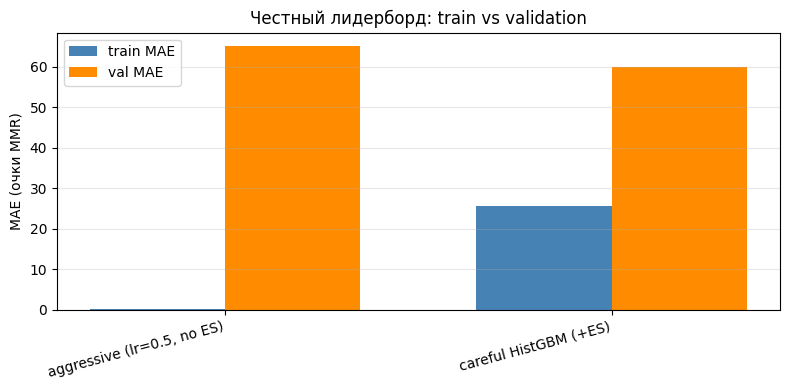

In [7]:
# --- Решение задания 4 ---
aggressive = HistGradientBoostingRegressor(
    learning_rate=0.5,
    max_iter=200,
    max_depth=8,
    early_stopping=False,
    random_state=RANDOM_STATE,
)
aggressive.fit(X_train, y_train)

careful = fixed_hist  # уже обучен в задании 2

honest_leaderboard = pd.DataFrame(
    [
        {
            "model": "aggressive (lr=0.5, no ES)",
            "train_MAE": mean_absolute_error(y_train, aggressive.predict(X_train)),
            "val_MAE": mean_absolute_error(y_val, aggressive.predict(X_val)),
        },
        {
            "model": "careful HistGBM (+ES)",
            "train_MAE": fixed_es_metrics["train_MAE"],
            "val_MAE": fixed_es_metrics["val_MAE"],
        },
    ]
)

interim_leader = honest_leaderboard.loc[honest_leaderboard["val_MAE"].idxmin(), "model"]
print(honest_leaderboard.to_string(index=False))
print("interim_leader =", interim_leader)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(honest_leaderboard))
width = 0.35
ax.bar(x - width / 2, honest_leaderboard["train_MAE"], width, label="train MAE", color="steelblue")
ax.bar(x + width / 2, honest_leaderboard["val_MAE"], width, label="val MAE", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(honest_leaderboard["model"], rotation=15, ha="right")
ax.set_ylabel("MAE (очки MMR)")
ax.set_title("Честный лидерборд: train vs validation")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


---
## Задание 5. Починить параметры и HistGBM-ориентир — **4 балла**

Тикет **BUG-E** (часть): `n_estimators=1` и безумные шаги — это не «ускорение», а отказ от модели. Зафиксируйте **починенный** sklearn-ориентир.

### Что сделать

**Шаг 1.** Обучите ориентир `repaired_histgbm` (`HistGradientBoostingRegressor`) с разумными параметрами и early stopping (можно опереться на идею задания 2, но сохраните отдельный объект и метрики).

**Шаг 2.** Посчитайте validation MAE/RMSE → `histgbm_metrics` (словарь через `evaluate_regression`).

**Шаг 3.** В переменной `param_fix_notes` (строка или список) кратко перечислите, какие кривые параметры из «Дано» вы отвергли (n_estimators=1, lr=1.5, …).

**Шаг 4.** (Опционально, но желательно) line-график: если есть staged-кривая аккуратной модели — покажите, что val не «взрывается».

### Подробные критерии (для проверки LLM)
- **1.5 балла:** `repaired_histgbm` обучен с early stopping и умеренным `learning_rate`.
- **1.5 балла:** есть `histgbm_metrics` с MAE на validation.
- **1.0 балл:** `param_fix_notes` явно указывает ≥ 2 кривых параметра из «Дано».

### Снижение баллов
- Модель с `n_estimators`/`max_iter` ≤ 5 без объяснения → минус **1.5**.
- Метрики на train/test вместо val → минус **1.0**.


In [8]:
# --- Решение задания 5 ---
t0 = time.perf_counter()
repaired_histgbm = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=RANDOM_STATE,
)
repaired_histgbm.fit(X_train, y_train)
hist_time = time.perf_counter() - t0

histgbm_metrics = evaluate_regression(
    "HistGBM repaired (+ES)",
    y_val,
    repaired_histgbm.predict(X_val),
    fit_time_sec=hist_time,
)
print("n_iter_ =", repaired_histgbm.n_iter_)
print(histgbm_metrics)

param_fix_notes = [
    "отвергли n_estimators=1 у XGBoost («для скорости» — модель почти константа)",
    "отвергли learning_rate=1.5 у LightGBM и 0.9 у CatBoost без early stopping",
    "отвергли early_stopping=False при большом числе итераций",
]
param_fix_notes


n_iter_ = 222
{'model': 'HistGBM repaired (+ES)', 'MAE': 59.88659322857218, 'RMSE': 77.0377968638992, 'R2': 0.9936427448205182, 'fit_time_sec': 0.33239590004086494}


['отвергли n_estimators=1 у XGBoost («для скорости» — модель почти константа)',
 'отвергли learning_rate=1.5 у LightGBM и 0.9 у CatBoost без early stopping',
 'отвергли early_stopping=False при большом числе итераций']

---
## Задание 6. Внешние бустинги после ремонта — **7 баллов**

Центр практики: после починки протокола сравните **XGBoost**, **LightGBM**, **CatBoost** на одних и тех же `X_train` / `X_val`.

### Что сделать

**Шаг 1.** Импортируйте `XGBRegressor`, `LGBMRegressor`, `CatBoostRegressor`.

**Шаг 2.** Обучите каждую модель с умеренным `learning_rate` (~0.05), достаточным числом деревьев/итераций (≥ 300) и **early stopping по validation** (`eval_set` / callbacks). Засеките время.

**Шаг 3.** Соберите `external_results` — ровно 3 строки внешних моделей, колонки как минимум `model`, `MAE`, `RMSE` (желательно `fit_time_sec`). Метрики на **validation**.

**Шаг 4.** Выведите `best_iteration` / `best_iteration_` / аналог для каждой библиотеки.

### Подробные критерии (для проверки LLM)
- **1.5 балла:** корректно импортированы все три внешние модели.
- **3.0 балла:** обучены XGBoost, LightGBM и CatBoost без ошибок (по **1.0** за модель).
- **1.5 балла:** у ≥ 2 моделей early stopping / `eval_set` на validation.
- **1.0 балл:** есть `external_results` с тремя строками и MAE/RMSE на val.

### Снижение баллов
- Нет одной из трёх библиотек → минус **1.0** за каждую.
- Метрики не на validation → минус **1.5**.
- Нет early stopping ни у одной → минус **1.0**.
- Остались параметры уровня BUG-E (`n_estimators=1`, lr ≥ 1 без ES) → минус **1.0**.


In [9]:
# --- Решение задания 6 ---
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping as lgb_early_stopping
from catboost import CatBoostRegressor

external_rows = []

# --- XGBoost ---
t0 = time.perf_counter()
xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    objective="reg:squarederror",
    early_stopping_rounds=40,
    n_jobs=-1,
)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_time = time.perf_counter() - t0
external_rows.append(
    evaluate_regression("XGBoost", y_val, xgb.predict(X_val), fit_time_sec=xgb_time)
)
print("XGBoost best_iteration:", getattr(xgb, "best_iteration", None))

# --- LightGBM ---
t0 = time.perf_counter()
lgbm = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    verbosity=-1,
)
lgbm.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l1",
    callbacks=[lgb_early_stopping(stopping_rounds=40, verbose=False)],
)
lgbm_time = time.perf_counter() - t0
external_rows.append(
    evaluate_regression("LightGBM", y_val, lgbm.predict(X_val), fit_time_sec=lgbm_time)
)
print("LightGBM best_iteration_:", getattr(lgbm, "best_iteration_", None))

# --- CatBoost ---
t0 = time.perf_counter()
cbr = CatBoostRegressor(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=RANDOM_STATE,
    verbose=0,
    early_stopping_rounds=40,
)
cbr.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)
cbr_time = time.perf_counter() - t0
external_rows.append(
    evaluate_regression("CatBoost", y_val, cbr.predict(X_val), fit_time_sec=cbr_time)
)
print("CatBoost best_iteration_:", getattr(cbr, "best_iteration_", None))

external_results = pd.DataFrame(external_rows)
external_results


XGBoost best_iteration: 354


LightGBM best_iteration_: 135


CatBoost best_iteration_: 217


,model,MAE,RMSE,R2,fit_time_sec
0,XGBoost,68.654318,85.388724,0.992190,0.376048
1,LightGBM,57.158525,72.262083,0.994407,0.320081
2,CatBoost,70.505907,90.229895,0.991279,0.602250


---
## Задание 7. Рейтинг и честный test — **3 балла**

Тикет **BUG-F**: test нельзя использовать для выбора модели. Сначала рейтинг по validation, потом **один** замер победителя на test.

### Что сделать

**Шаг 1.** Соберите `final_ranking` = HistGBM-ориентир + три внешние модели; отсортируйте по возрастанию **validation MAE**.

**Шаг 2.** Bar-график validation MAE по моделям (заголовок + подписи осей).

**Шаг 3.** Зафиксируйте `winner_name` по val. Посчитайте `winner_test_mae` **один раз**. В markdown (1 предложение): почему нельзя было выбирать победителя по test, как в «Дано».

### Подробные критерии (для проверки LLM)
- **1.0 балл:** `final_ranking` содержит ≥ 4 моделей и отсортирован по val MAE.
- **1.0 балл:** bar-график validation MAE с заголовком и подписями.
- **1.0 балл:** есть `winner_name`, `winner_test_mae` и объяснение про запрет выбора по test.

### Снижение баллов
- Победитель выбран по test → минус **1.0**.
- Нет графика → минус **0.5**.
- Нет test-замера победителя → минус **0.5**.


                 model       MAE      RMSE       R2  fit_time_sec
              LightGBM 57.158525 72.262083 0.994407      0.320081
HistGBM repaired (+ES) 59.886593 77.037797 0.993643      0.332396
               XGBoost 68.654318 85.388724 0.992190      0.376048
              CatBoost 70.505907 90.229895 0.991279      0.602250


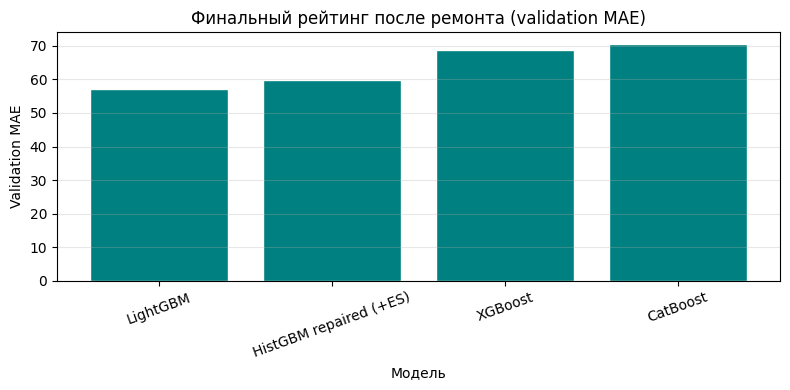

winner_name = LightGBM
winner_test_mae = 56.2
winner_val_mae = 57.16


In [10]:
# --- Решение задания 7 ---
final_ranking = pd.concat(
    [
        pd.DataFrame([histgbm_metrics]),
        external_results.copy(),
    ],
    ignore_index=True,
).sort_values("MAE").reset_index(drop=True)

print(final_ranking.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(final_ranking["model"], final_ranking["MAE"], color="teal", edgecolor="white")
ax.set_title("Финальный рейтинг после ремонта (validation MAE)")
ax.set_xlabel("Модель")
ax.set_ylabel("Validation MAE")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

winner_name = str(final_ranking.iloc[0]["model"])
winner_model = {
    "HistGBM repaired (+ES)": repaired_histgbm,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cbr,
}[winner_name]

winner_test_mae = float(mean_absolute_error(y_test, winner_model.predict(X_test)))
print("winner_name =", winner_name)
print("winner_test_mae =", round(winner_test_mae, 2))
print("winner_val_mae =", round(float(final_ranking.iloc[0]["MAE"]), 2))


*Почему нельзя выбирать по test?*

Test — имитация будущих игроков «в бою». Если перебирать модели, глядя на test MAE (как `fake_winner` в «Дано»), мы подстраиваемся под эту выборку и больше не знаем честную оценку качества после выката.


---
## Задание 8. Postmortem — **2 балла**

Короткий разбор для канала Control Room (markdown, 4–6 предложений или маркированный список).

### Что сделать

Структура обязательна:

1. **Что сломалось** — перечислите ключевые BUG-* из «Дано» своими словами.
2. **Как починили** — что изменили в протоколе (split → fit preprocessing → early stopping по val → сравнение по val MAE).
3. **Кого выкатываем** — `winner_name`, validation MAE и одноразовый test MAE.
4. **Правило на завтра** — одна фраза-страховка для дежурного.

### Подробные критерии (для проверки LLM)
- **0.5 балла:** описано ≥ 3 поломки из инцидента.
- **0.5 балла:** описан ремонт протокола (не только «поставили другую библиотеку»).
- **0.5 балла:** указан победитель и его val/test MAE (или ссылка на переменные с числами).
- **0.5 балла:** есть правило-страховка на будущее.

### Снижение баллов
- Postmortem без чисел/имён моделей → минус **0.5**.
- Нет блока «кого выкатываем» → минус **0.5**.


### Postmortem (авторский ответ)

**Что сломалось.** В «ускоренном» пайплайне одновременно жили: утечка scaler на всём `X` (**BUG-A**), огромный `learning_rate` без early stopping (**BUG-B**), «монитор» по train (**BUG-C**), лидерборд только по train MAE (**BUG-D**), внешние модели с `n_estimators=1` / безумными шагами (**BUG-E**) и выбор победителя по test (**BUG-F**). На графике это выглядело как train↓ / val↑.

**Как починили.** Сначала честный split, затем `StandardScaler.fit` только на train. Early stopping и сравнение моделей — строго по validation MAE. Кривые параметры внешних библиотек заменили на умеренный шаг + early stopping по `eval_set`.

**Кого выкатываем.** Победитель — модель из `winner_name` после сортировки `final_ranking` по validation MAE; test трогали один раз (`winner_test_mae`).

**Правило на завтра.** «Зелёный train и красивый test при выборе модели — красный флаг: смотри validation и early stopping.»


---
## Итог практики

Вы отработали не «ещё один бенчмарк библиотек», а **дежурство**: воспроизвели инцидент, починили типичные поломки бустинга и только потом сравнили XGBoost / LightGBM / CatBoost на честном протоколе.

**Главная мысль.** Бустинг легко выглядит сильным на train. Сила в проде — маленький шаг, early stopping по validation, preprocessing без утечки и один финальный взгляд на test.
